<a href="https://colab.research.google.com/github/kousikuppalapati/Machine-Learning-Lab/blob/main/MLWEEK9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import Libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
#Load MNIST dataset
mnist = fetch_openml('mnist_784')
X=mnist.data
Y=mnist.target.astype(int)

In [3]:
print("dataset shape: ",X.shape)

dataset shape:  (70000, 784)


In [4]:
#Train Test Split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [5]:
#Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
#simple perceptron
perceptron = Perceptron()
perceptron.fit(X_train, Y_train)
Y_pred = perceptron.predict(X_test)
perceptron_accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9729285714285715


In [12]:
#Multi Layer perceptron
mlp = MLPClassifier(hidden_layer_sizes=(100,),max_iter=20,random_state=42)
mlp.fit(X_train, Y_train)
Y_pred = mlp.predict(X_test)
mlp_accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9729285714285715


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
print("\nPerformance Comparison")
print("Perceptron Accuracy : {:.2f}%".format(perceptron_accuracy * 100))
print("MLP Accuracy : {:.2f}%".format(mlp_accuracy * 100))


Performance Comparison
Perceptron Accuracy : 87.59%
MLP Accuracy : 97.29%


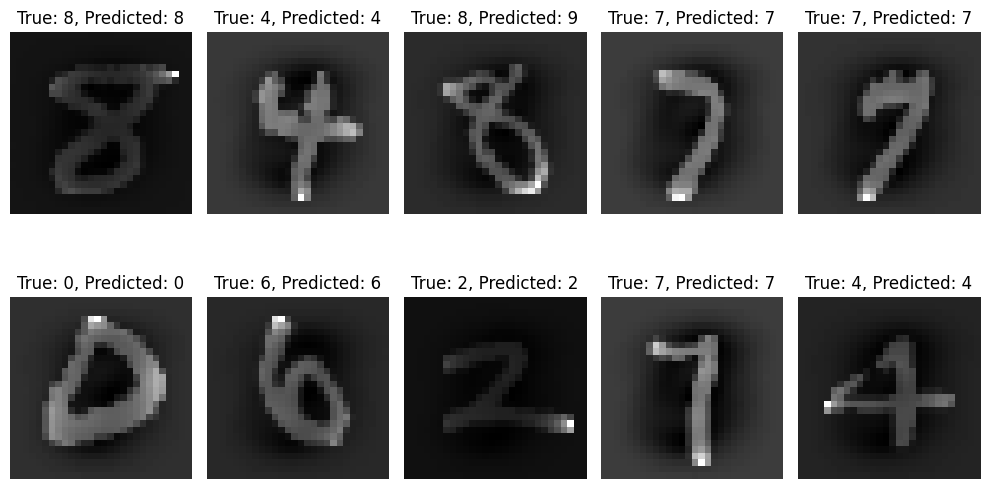

In [18]:
#Visualization
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i +1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {Y_test.iloc[i]}, Predicted: {Y_pred[i]}")
    plt.axis('off')
plt.tight_layout()